# Cybercrime Network Intrusion Analysis

## Project overview

This project analyses network traffic from the RT-IoT2022 dataset to identify malicious activity and support cybersecurity incident triage.

## Objectives

- inspect and clean network traffic data
- distinguish normal traffic from cyberattacks
- analyse the frequency and characteristics of attack types
- build and evaluate an intrusion detection model
- identify the most important indicators of malicious activity
- create SQL queries supporting incident investigation
- discuss false positives, false negatives and responsible use

> This project is for educational and portfolio purposes. It is not a production intrusion detection system.

In [1]:
from pathlib import Path
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
VISUALS_DIR = PROJECT_ROOT / "visuals"

for directory in [RAW_DATA_DIR, PROCESSED_DATA_DIR, VISUALS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Libraries and project paths loaded successfully.")

Libraries and project paths loaded successfully.


In [2]:
# Download the RT-IoT2022 network traffic dataset from UCI
rt_iot2022 = fetch_ucirepo(id=942)

features = rt_iot2022.data.features.copy()
target = rt_iot2022.data.targets.copy()

df = pd.concat([features, target], axis=1)

print("Dataset downloaded successfully.")
print("Dataset shape:", df.shape)
print("Target column:", target.columns.tolist())

display(df.head())

Dataset downloaded successfully.
Dataset shape: (123117, 84)
Target column: ['Attack_type']


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,761.985779,29729182.96,32011597.87,4001449.734,10403073.63,4438.877106,1511693.954,2.026391e+06,506597.757339,680406.147100,761.985779,29729182.96,32011597.87,2.462431e+06,8.199747e+06,3.373777,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2282414.913,2282414.913,2282414.913,2282414.913,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,247.001648,29855277.06,31883584.02,3985448.003,10463455.56,4214.048386,1576435.804,1.876261e+06,469065.249000,741351.686200,247.001648,29855277.06,31883584.02,2.452583e+06,8.242459e+06,3.387323,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2028306.961,2028306.961,2028306.961,2028306.961,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,74,8.222222,12.852799,0,21,30,6.0,8.689074,0,33,104,7.428571,11.229866,283.956528,29842149.02,32124053.00,4015506.625,10442377.92,2456.903458,1476048.946,2.013770e+06,503442.466300,660344.360027,283.956528,29842149.02,32124053.00,2.471081e+06,8.230593e+06,3.237450,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2281903.982,2281903.982,2281903.982,2281903.982,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,74,8.222222,12.852799,0,21,30,6.0,8.689074,0,33,104,7.428571,11.229866,288.963318,29913774.97,31961063.15,3995132.893,10482528.22,3933.906555,1551892.042,1.883784e+06,470946.013927,724569.317900,288.963318,29913774.97,31961063.15,2.458543e+06,8.257786e+06,3.253959,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2047288.179,2047288.179,2047288.179,2047288.179,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,387.907028,29814704.90,31902361.87,3987795.234,10447019.10,3005.027771,1632083.178,1.935984e+06,483996.033700,768543.390313,387.907028,2981

In [3]:
# Data quality assessment
quality_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values(
    by=["missing_values", "unique_values"],
    ascending=[False, True]
)

duplicated_rows = df.duplicated().sum()

numeric_data = df.select_dtypes(include=np.number)
infinite_values = np.isinf(numeric_data).sum().sum()

print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])
print("Duplicated rows:", duplicated_rows)
print("Infinite numeric values:", infinite_values)

print("\nAttack type distribution:")
display(
    df["Attack_type"]
    .value_counts()
    .rename_axis("attack_type")
    .reset_index(name="records")
)

print("\nColumns with missing values:")
display(quality_summary[quality_summary["missing_values"] > 0])

print("\nData types:")
display(quality_summary.head(20))

Number of rows: 123117
Number of columns: 84
Duplicated rows: 5195
Infinite numeric values: 0

Attack type distribution:


,attack_type,records
0,DOS_SYN_Hping,94659
1,Thing_Speak,8108
2,ARP_poisioning,7750
3,MQTT_Publish,4146
4,NMAP_UDP_SCAN,2590
5,NMAP_XMAS_TREE_SCAN,2010
6,NMAP_OS_DETECTION,2000
7,NMAP_TCP_scan,1002
8,DDOS_Slowloris,534
9,Wipro_bulb,253



Columns with missing values:


,data_type,missing_values,missing_pct,unique_values



Data types:


,data_type,missing_values,missing_pct,unique_values
bwd_URG_flag_count,int64,0,0.0,1
fwd_URG_flag_count,int64,0,0.0,2
proto,object,0,0.0,3
flow_CWR_flag_count,int64,0,0.0,5
flow_ECE_flag_count,int64,0,0.0,5
fwd_header_size_min,int64,0,0.0,7
bwd_header_size_min,int64,0,0.0,7
fwd_header_size_max,int64,0,0.0,8
flow_SYN_flag_count,int64,0,0.0,8
bwd_header_size_max,int64,0,0.0,9


In [4]:
# Clean column names and prepare analysis dataset
analysis = df.copy()

analysis.columns = (
    analysis.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

analysis = analysis.replace([np.inf, -np.inf], np.nan)
analysis = analysis.drop_duplicates().reset_index(drop=True)

# Remove columns containing only one value
constant_columns = [
    column for column in analysis.columns
    if column != "attack_type" and analysis[column].nunique(dropna=False) <= 1
]

analysis = analysis.drop(columns=constant_columns)

# Identify normal IoT traffic
normal_keywords = ["mqtt", "thing", "wipro"]

analysis["is_attack"] = (
    ~analysis["attack_type"]
    .str.lower()
    .str.contains("|".join(normal_keywords), na=False)
).astype(int)

def assign_attack_category(label):
    label = str(label).lower()

    if any(keyword in label for keyword in normal_keywords):
        return "Normal traffic"
    if "ddos" in label or "dos" in label:
        return "DoS / DDoS"
    if "nmap" in label or "scan" in label:
        return "Network scanning"
    if "arp" in label:
        return "ARP poisoning"
    if "brute" in label or "metasploit" in label:
        return "Brute-force attack"
    return "Other attack"

analysis["attack_category"] = analysis["attack_type"].apply(
    assign_attack_category
)

print("Rows after cleaning:", len(analysis))
print("Columns after cleaning:", analysis.shape[1])
print("Removed constant columns:", constant_columns)
print("Remaining missing values:", analysis.isna().sum().sum())

print("\nDetailed traffic labels:")
print(analysis["attack_type"].value_counts().to_string())

print("\nIncident categories:")
display(
    analysis["attack_category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="records")
)

print("\nBinary target:")
display(
    analysis["is_attack"]
    .value_counts()
    .rename(index={0: "Normal", 1: "Attack"})
    .rename_axis("traffic_type")
    .reset_index(name="records")
)

Rows after cleaning: 117922
Columns after cleaning: 85
Removed constant columns: ['bwd_urg_flag_count']
Remaining missing values: 0

Detailed traffic labels:
attack_type
DOS_SYN_Hping                 90089
Thing_Speak                    7654
ARP_poisioning                 7625
MQTT_Publish                   4142
NMAP_UDP_SCAN                  2584
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  533
Wipro_bulb                      219
Metasploit_Brute_Force_SSH       36
NMAP_FIN_SCAN                    28

Incident categories:


,category,records
0,DoS / DDoS,90622
1,Normal traffic,12015
2,ARP poisoning,7625
3,Network scanning,7624
4,Brute-force attack,36



Binary target:


,traffic_type,records
0,Attack,105907
1,Normal,12015


In [5]:
# Save the cleaned dataset and a small incident summary
clean_data_path = (
    PROCESSED_DATA_DIR / "network_traffic_clean.csv.gz"
)

analysis.to_csv(
    clean_data_path,
    index=False,
    compression="gzip"
)

incident_summary = (
    analysis["attack_category"]
    .value_counts()
    .rename_axis("attack_category")
    .reset_index(name="records")
)

incident_summary["percentage"] = (
    incident_summary["records"] / len(analysis) * 100
).round(2)

incident_summary.to_csv(
    PROCESSED_DATA_DIR / "incident_category_summary.csv",
    index=False
)

file_size_mb = clean_data_path.stat().st_size / (1024 ** 2)

print("Clean dataset saved successfully.")
print("Clean dataset shape:", analysis.shape)
print(f"Compressed file size: {file_size_mb:.2f} MB")

display(incident_summary)

Clean dataset saved successfully.
Clean dataset shape: (117922, 85)
Compressed file size: 2.81 MB


,attack_category,records,percentage
0,DoS / DDoS,90622,76.85
1,Normal traffic,12015,10.19
2,ARP poisoning,7625,6.47
3,Network scanning,7624,6.47
4,Brute-force attack,36,0.03


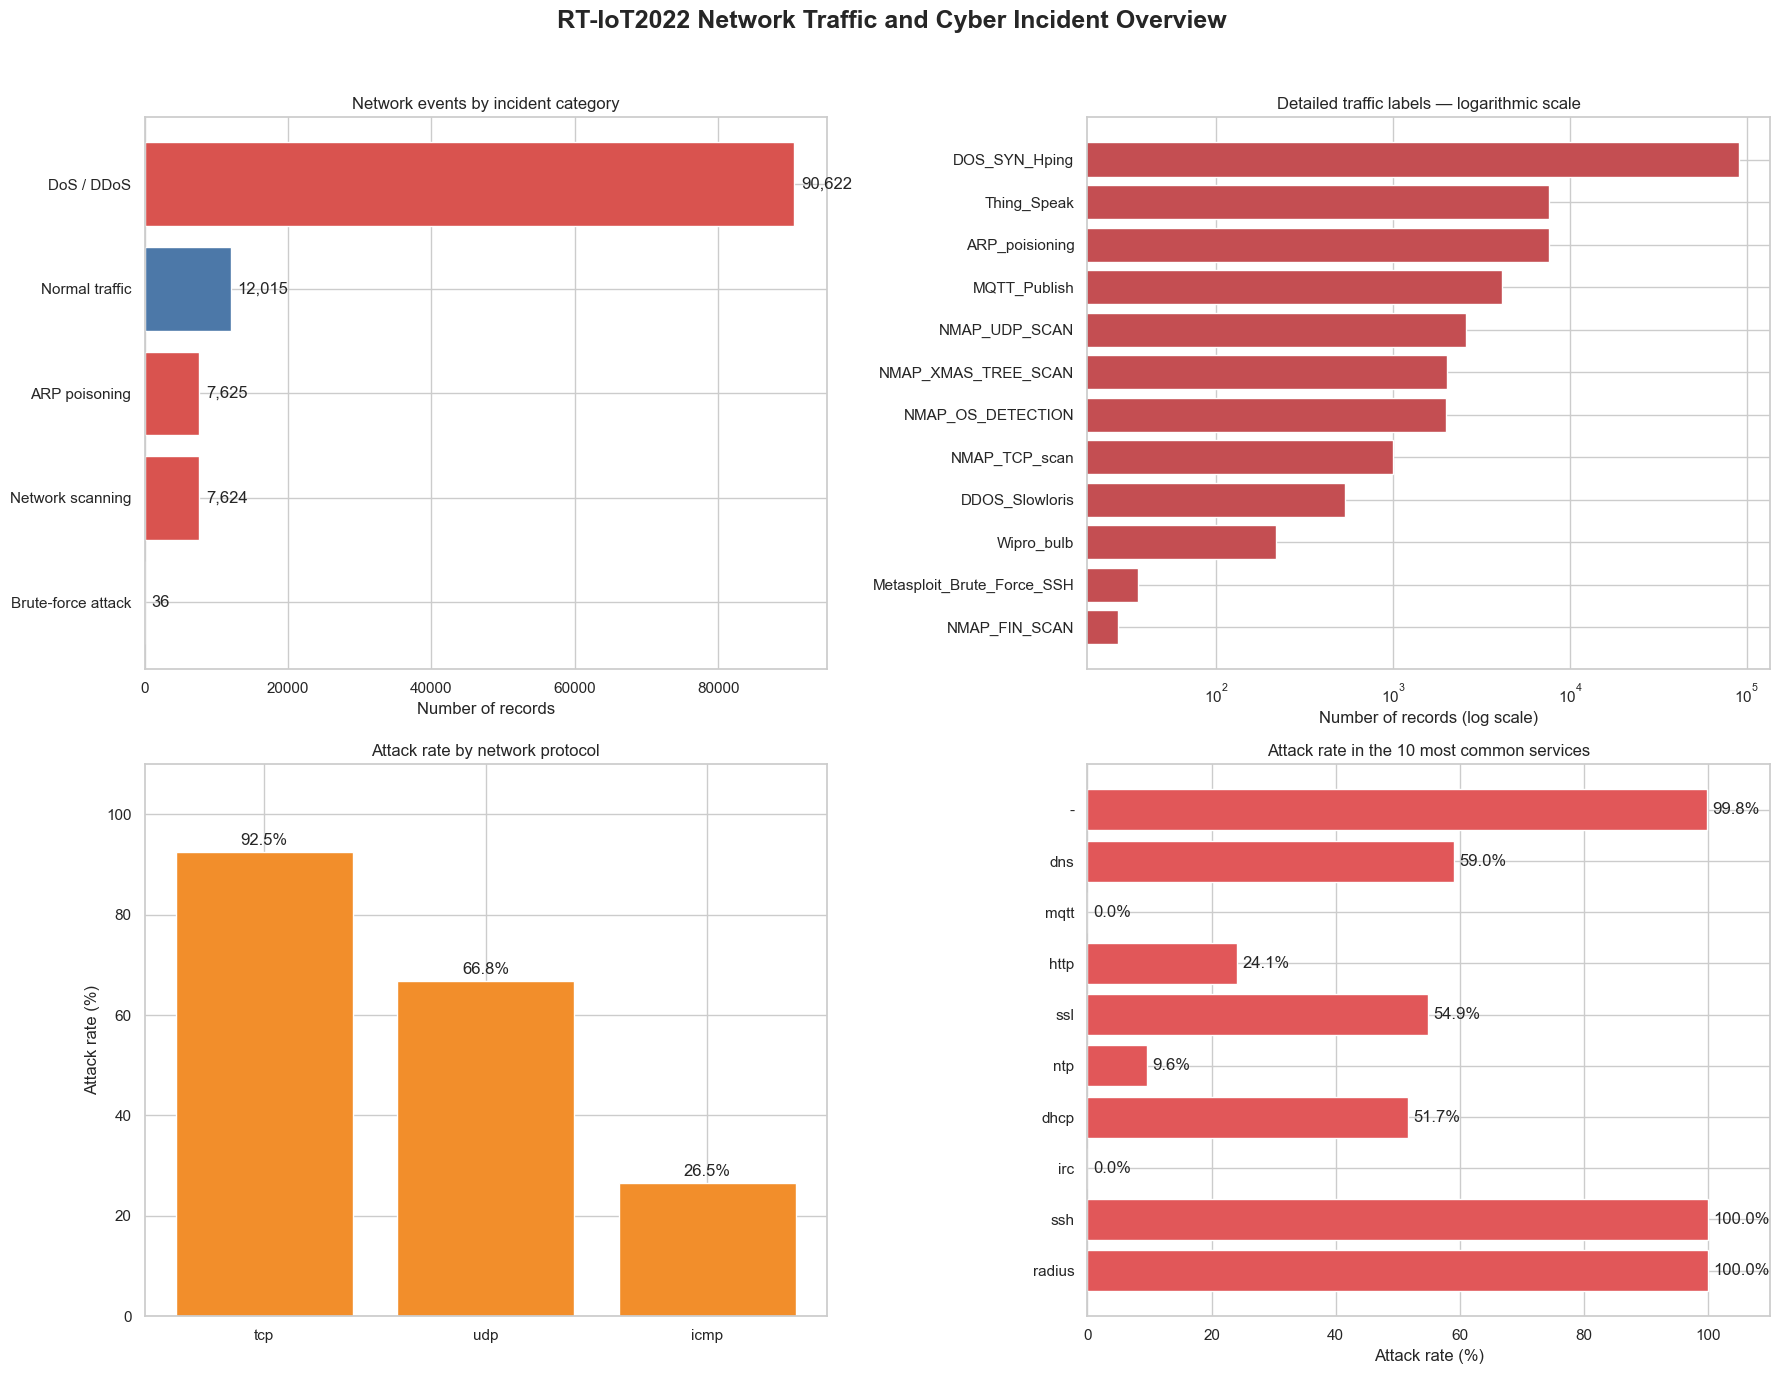

In [6]:
# Exploratory analysis of network traffic and cyber incidents
category_counts = (
    analysis["attack_category"]
    .value_counts()
    .sort_values()
)

detailed_counts = (
    analysis["attack_type"]
    .value_counts()
    .sort_values()
)

protocol_summary = (
    analysis.groupby("proto")
    .agg(
        records=("is_attack", "size"),
        attack_rate=("is_attack", "mean")
    )
    .sort_values("records", ascending=False)
)

protocol_summary["attack_rate"] *= 100

service_summary = (
    analysis.groupby("service")
    .agg(
        records=("is_attack", "size"),
        attack_rate=("is_attack", "mean")
    )
    .sort_values("records", ascending=False)
    .head(10)
)

service_summary["attack_rate"] *= 100

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Incident categories
category_colors = [
    "#4C78A8" if category == "Normal traffic" else "#D9534F"
    for category in category_counts.index
]

bars = axes[0, 0].barh(
    category_counts.index,
    category_counts.values,
    color=category_colors
)

axes[0, 0].bar_label(
    bars,
    labels=[f"{value:,}" for value in category_counts.values],
    padding=5
)

axes[0, 0].set_title("Network events by incident category")
axes[0, 0].set_xlabel("Number of records")

# 2. Detailed labels on logarithmic scale
bars = axes[0, 1].barh(
    detailed_counts.index,
    detailed_counts.values,
    color="#C44E52"
)

axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Detailed traffic labels — logarithmic scale")
axes[0, 1].set_xlabel("Number of records (log scale)")

# 3. Attack rate by protocol
bars = axes[1, 0].bar(
    protocol_summary.index.astype(str),
    protocol_summary["attack_rate"],
    color="#F28E2B"
)

axes[1, 0].bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in protocol_summary["attack_rate"]
    ],
    padding=3
)

axes[1, 0].set_title("Attack rate by network protocol")
axes[1, 0].set_ylabel("Attack rate (%)")
axes[1, 0].set_ylim(0, 110)

# 4. Attack rate in the most common services
bars = axes[1, 1].barh(
    service_summary.index.astype(str)[::-1],
    service_summary["attack_rate"][::-1],
    color="#E15759"
)

axes[1, 1].bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in service_summary["attack_rate"][::-1]
    ],
    padding=4
)

axes[1, 1].set_title("Attack rate in the 10 most common services")
axes[1, 1].set_xlabel("Attack rate (%)")
axes[1, 1].set_xlim(0, 110)

fig.suptitle(
    "RT-IoT2022 Network Traffic and Cyber Incident Overview",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    VISUALS_DIR / "cybercrime_traffic_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Prepare features and binary target
X = analysis.drop(
    columns=["attack_type", "attack_category", "is_attack"]
)

y = analysis["is_attack"]

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=18,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        )
    )
])

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Numeric features:", len(numeric_columns))
print("Categorical features:", categorical_columns)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

model_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 score",
        "ROC-AUC"
    ],
    "value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_probability)
    ]
})

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"]
    )
)

display(model_metrics.round(4))

Training rows: 94337
Test rows: 23585
Numeric features: 80
Categorical features: ['proto', 'service']

Classification report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      2403
      Attack       1.00      1.00      1.00     21182

    accuracy                           1.00     23585
   macro avg       1.00      1.00      1.00     23585
weighted avg       1.00      1.00      1.00     23585



,metric,value
0,Accuracy,0.9985
1,Precision,0.9992
2,Recall,0.9991
3,F1 score,0.9992
4,ROC-AUC,1.0000


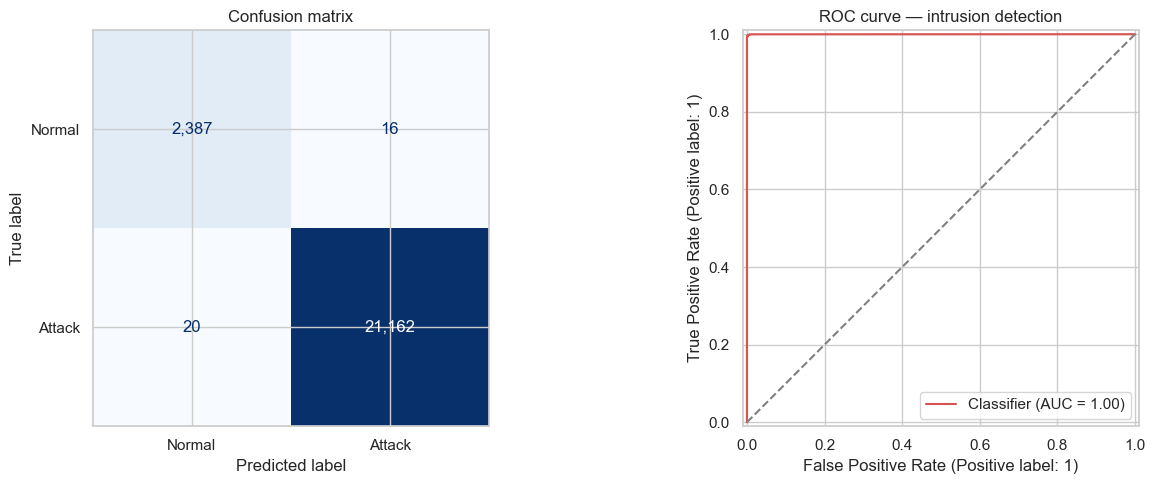

False negatives — missed attacks: 20
False positives — false alarms: 16

Examples of missed attacks:


,proto,service,actual,predicted,attack_probability
14108,udp,dns,1,0,0.117947
16855,udp,dns,1,0,0.136324
18358,udp,dns,1,0,0.218414
16767,udp,dns,1,0,0.252750
15289,udp,dns,1,0,0.263183
12066,udp,dns,1,0,0.323798
15270,udp,dhcp,1,0,0.328002
16554,udp,dns,1,0,0.350700
12078,udp,dns,1,0,0.384097
16585,udp,dns,1,0,0.389697


In [8]:
# Model performance and incident classification errors
confusion = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Normal", "Attack"]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format=","
)

axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    ax=axes[1],
    color="#D9534F"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

axes[1].set_title("ROC curve — intrusion detection")

plt.tight_layout()

plt.savefig(
    VISUALS_DIR / "intrusion_detection_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Create an investigation table for incorrect classifications
prediction_results = X_test[
    ["proto", "service"]
].copy()

prediction_results["actual"] = y_test
prediction_results["predicted"] = y_pred
prediction_results["attack_probability"] = y_probability

false_negatives = prediction_results[
    (prediction_results["actual"] == 1) &
    (prediction_results["predicted"] == 0)
].sort_values("attack_probability")

false_positives = prediction_results[
    (prediction_results["actual"] == 0) &
    (prediction_results["predicted"] == 1)
].sort_values(
    "attack_probability",
    ascending=False
)

print("False negatives — missed attacks:", len(false_negatives))
print("False positives — false alarms:", len(false_positives))

print("\nExamples of missed attacks:")
display(false_negatives.head(10))

model_metrics.to_csv(
    PROCESSED_DATA_DIR / "model_metrics.csv",
    index=False
)

,threshold,precision,recall,f1_score,missed_attacks,false_alarms
2,0.2,0.9972,0.9999,0.9985,2,60
4,0.3,0.9982,0.9998,0.9990,5,39
6,0.4,0.9990,0.9994,0.9992,12,22
8,0.5,0.9992,0.9991,0.9992,20,16
10,0.6,0.9994,0.9987,0.9991,27,13


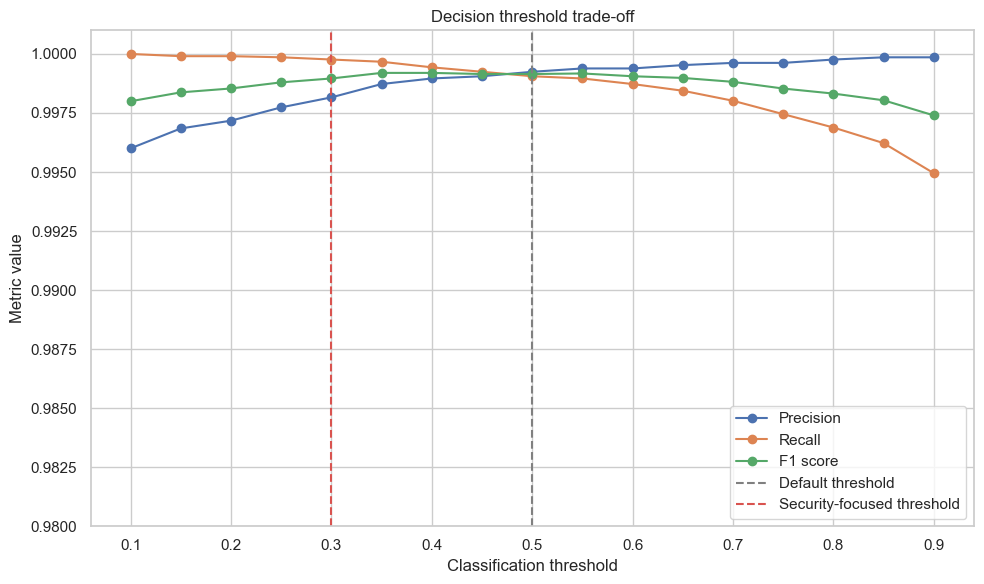

Security-focused threshold:


,threshold,precision,recall,f1_score,missed_attacks,false_alarms
4,0.3,0.9982,0.9998,0.999,5,39


In [9]:
# Decision-threshold analysis for security incident triage
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    threshold_predictions = (
        y_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        threshold_predictions,
        labels=[0, 1]
    ).ravel()

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "missed_attacks": fn,
        "false_alarms": fp
    })

threshold_analysis = pd.DataFrame(threshold_results)

display(
    threshold_analysis[
        threshold_analysis["threshold"].isin(
            [0.20, 0.30, 0.40, 0.50, 0.60]
        )
    ].round(4)
)

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["f1_score"],
    marker="o",
    label="F1 score"
)

plt.axvline(
    0.50,
    color="gray",
    linestyle="--",
    label="Default threshold"
)

plt.axvline(
    0.30,
    color="#D9534F",
    linestyle="--",
    label="Security-focused threshold"
)

plt.title("Decision threshold trade-off")
plt.xlabel("Classification threshold")
plt.ylabel("Metric value")
plt.ylim(0.98, 1.001)
plt.legend()
plt.tight_layout()

plt.savefig(
    VISUALS_DIR / "decision_threshold_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

operational_result = threshold_analysis[
    threshold_analysis["threshold"] == 0.30
]

print("Security-focused threshold:")
display(operational_result.round(4))

threshold_analysis.to_csv(
    PROCESSED_DATA_DIR / "threshold_analysis.csv",
    index=False
)

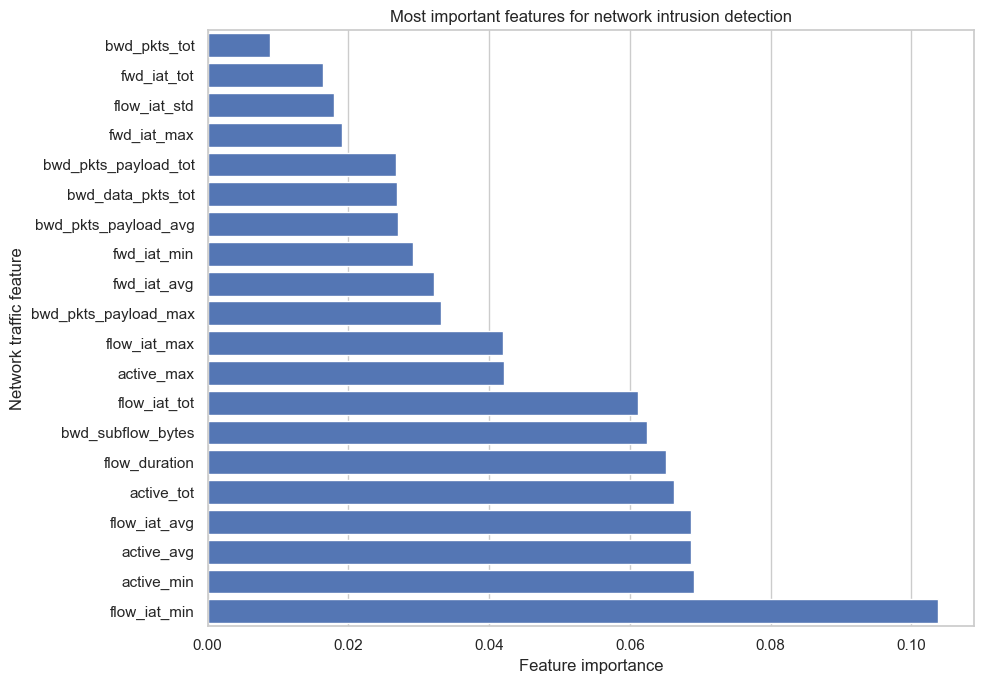

,feature,importance
51,flow_iat_min,0.103699
67,active_min,0.069143
70,active_avg,0.068739
54,flow_iat_avg,0.068703
69,active_tot,0.066275
2,flow_duration,0.065118
60,bwd_subflow_bytes,0.062447
53,flow_iat_tot,0.061141
68,active_max,0.042162
52,flow_iat_max,0.041989


In [10]:
# Feature importance

feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = model.named_steps["classifier"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

# Remove technical prefixes added by the preprocessing pipeline
feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace(r"^(numeric|categorical)__", "", regex=True)
)

top_features = feature_importance.head(20).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    color="#4472C4"
)

plt.title("Most important features for network intrusion detection")
plt.xlabel("Feature importance")
plt.ylabel("Network traffic feature")
plt.tight_layout()

plt.savefig(
    VISUALS_DIR / "intrusion_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

feature_importance.to_csv(
    PROCESSED_DATA_DIR / "feature_importance.csv",
    index=False
)

display(feature_importance.head(20))

In [11]:
# Create a compact SQLite database for incident investigation

database_columns = [
    "id_orig_p",
    "id_resp_p",
    "proto",
    "service",
    "flow_duration",
    "fwd_pkts_tot",
    "bwd_pkts_tot",
    "attack_type",
    "attack_category",
    "is_attack"
]

available_columns = [
    column for column in database_columns
    if column in analysis.columns
]

investigation_data = analysis[available_columns].copy()

database_path = PROCESSED_DATA_DIR / "cybercrime_incidents.db"

with sqlite3.connect(database_path) as connection:
    investigation_data.to_sql(
        "network_incidents",
        connection,
        if_exists="replace",
        index=False
    )

    incident_summary.to_sql(
        "incident_summary",
        connection,
        if_exists="replace",
        index=False
    )

    connection.execute(
        """
        CREATE INDEX IF NOT EXISTS idx_attack_category
        ON network_incidents (attack_category)
        """
    )

    connection.execute(
        """
        CREATE INDEX IF NOT EXISTS idx_protocol
        ON network_incidents (proto)
        """
    )

print("SQLite database saved successfully.")
print("Database path:", database_path)
print("Rows saved:", len(investigation_data))
print("Columns saved:", available_columns)

with sqlite3.connect(database_path) as connection:
    sql_preview = pd.read_sql_query(
        """
        SELECT
            attack_category,
            COUNT(*) AS records
        FROM network_incidents
        GROUP BY attack_category
        ORDER BY records DESC
        """,
        connection
    )

display(sql_preview)

SQLite database saved successfully.
Database path: ../data/processed/cybercrime_incidents.db
Rows saved: 117922
Columns saved: ['id_orig_p', 'id_resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'attack_type', 'attack_category', 'is_attack']


,attack_category,records
0,DoS / DDoS,90622
1,Normal traffic,12015
2,ARP poisoning,7625
3,Network scanning,7624
4,Brute-force attack,36


In [12]:
# Create the SQL analysis file

sql_content = """
-- Cybercrime Network Intrusion Analysis
-- Portfolio SQL queries for investigating network incidents


-- 1. Distribution of incident categories

SELECT
    attack_category,
    COUNT(*) AS records,
    ROUND(
        100.0 * COUNT(*) /
        (SELECT COUNT(*) FROM network_incidents),
        2
    ) AS percentage
FROM network_incidents
GROUP BY attack_category
ORDER BY records DESC;


-- 2. Attacks by network protocol

SELECT
    proto,
    COUNT(*) AS attack_records
FROM network_incidents
WHERE is_attack = 1
GROUP BY proto
ORDER BY attack_records DESC;


-- 3. Attack rate by protocol

SELECT
    proto,
    COUNT(*) AS total_records,
    SUM(is_attack) AS attacks,
    ROUND(
        100.0 * SUM(is_attack) / COUNT(*),
        2
    ) AS attack_rate_pct
FROM network_incidents
GROUP BY proto
ORDER BY attack_rate_pct DESC;


-- 4. Most frequently targeted services

SELECT
    service,
    COUNT(*) AS attack_records
FROM network_incidents
WHERE is_attack = 1
GROUP BY service
ORDER BY attack_records DESC
LIMIT 10;


-- 5. Average flow duration by incident category

SELECT
    attack_category,
    ROUND(AVG(flow_duration), 2) AS average_flow_duration,
    COUNT(*) AS records
FROM network_incidents
GROUP BY attack_category
ORDER BY records DESC;


-- 6. Most frequently targeted destination ports

SELECT
    id_resp_p AS destination_port,
    COUNT(*) AS attack_records
FROM network_incidents
WHERE is_attack = 1
GROUP BY id_resp_p
ORDER BY attack_records DESC
LIMIT 10;


-- 7. Detailed attack types

SELECT
    attack_type,
    attack_category,
    COUNT(*) AS records
FROM network_incidents
WHERE is_attack = 1
GROUP BY attack_type, attack_category
ORDER BY records DESC;
"""

sql_file_path = PROJECT_ROOT / "sql" / "cybercrime_analysis.sql"

sql_file_path.write_text(
    sql_content.strip(),
    encoding="utf-8"
)

print("SQL analysis file saved successfully.")
print("File:", sql_file_path)

SQL analysis file saved successfully.
File: ../sql/cybercrime_analysis.sql


## Conclusions

This project analysed 117,922 network traffic records to identify patterns associated with cyberattacks and normal activity.

### Key findings

- 89.81% of the analysed records represented malicious network activity.
- DoS and DDoS incidents were the dominant category, accounting for 76.85% of all records.
- The classification model achieved an F1 score of 0.9992 and detected 21,162 attacks in the test dataset.
- At the default decision threshold of 0.50, the model produced 20 missed attacks and 16 false alarms.
- A security-focused threshold of 0.30 reduced missed attacks to 5, while increasing false alarms to 39.
- Timing and activity-related network features, including `flow_iat_min`, `active_min`, `active_avg` and `flow_duration`, had the strongest influence on model predictions.

### Operational interpretation

In a cybersecurity context, missed attacks may present a greater risk than additional false alarms. Therefore, reducing the classification threshold can be appropriate when the priority is early detection and incident prevention.

### Limitations

The dataset was collected in a controlled IoT environment. The exceptionally high model performance may not transfer directly to real-world police or enterprise networks. Before operational use, the model would require validation on independent and more diverse network traffic, monitoring for data drift and regular retraining.

### Responsible use

The model should support security analysts rather than make autonomous enforcement decisions. Alerts require human verification and should be evaluated together with additional technical evidence and the applicable legal and data-protection requirements.